In [ ]:
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

a function that takes bands, pre-trained model, bands data with night npz and day npz(huge data)
output: 3 version of npz
version 1 raw data: output ghi_grid npz for csi and timestamp do not need to load band data
version 2 synthetic track: output synthict grid_grid that means for night time (where cs-GHI from ghi_grid is 0 for all points) find the matched nigh bands data and to predict the values of csi and time stamp
(true day + syn night) need to load night npz

version 3 synthetic track ++: output synthict grid_grid that means for night time(where cs-GHI from ghi_grid npz is 0 + the first and last day timestep for all points) use model to predict

true day[0:-1] + syn night need to load both night npz and day npz

band data and cams data are separated by my function to day without twillight and night with twilight. Band and cams are paired 1 by 1 according to time. with total (7941(day)+10068(night)). I have a pre-trained model that take bands to cams. I need you to write me a function to take band night with twilight as model input and ouput cams data at night. and re-combine cams day data and the model output accroding to time. if there is gap of time, print warning. 

another function should combine cams cams_day_paired_no_twillight and cams_night_paired_twillight.npz with repect to time without duplicate and also warning gap

In [2]:
import numpy as np

def combine_cams_day_and_night_by_time(
    cams_day_npz,
    cams_night_npz,
    *,
    time_key="time_min",
    data_key="data",
    keep_duplicate="last",   # "first" or "last"
    gap_factor=2.5,          # gap if dt > median_dt * gap_factor
    max_gap=None,            # optional absolute threshold in SAME units as time_min (minutes)
    warn_limit=20,
    return_report=True,
):
    """
    Combine cams day + cams night by sorting on time_min and deduping on time_min.
    """

    def _as_1d_time(t):
        t = np.asarray(t)
        if t.ndim != 1:
            raise ValueError(f"{time_key} must be 1D, got {t.shape}")
        return t

    def _check_first_dim(name, x, n):
        x = np.asarray(x)
        if x.shape[0] != n:
            raise ValueError(f"{name}.shape[0] must match len({time_key})={n}, got {x.shape}")
        return x

    def _median_positive_dt(t_sorted):
        if len(t_sorted) < 3:
            return None
        dt = np.diff(t_sorted)
        dt = dt[dt > 0]
        if len(dt) == 0:
            return None
        return float(np.median(dt))

    def _warn_gaps(t_sorted, label):
        if len(t_sorted) < 2:
            return
        dt = np.diff(t_sorted)
        med = _median_positive_dt(t_sorted)
        if med is None and max_gap is None:
            return

        bad = np.zeros_like(dt, dtype=bool)
        if med is not None:
            bad |= (dt > med * gap_factor)
        if max_gap is not None:
            bad |= (dt > max_gap)

        idx = np.flatnonzero(bad)
        for i in idx[:warn_limit]:
            msg = f"WARNING[{label}] gap: {t_sorted[i]} -> {t_sorted[i+1]} (dt={dt[i]}"
            if med is not None:
                msg += f", median_dt~{med}"
            msg += ")"
            print(msg)
        if len(idx) > warn_limit:
            print(f"WARNING[{label}] ... {len(idx) - warn_limit} more gaps not shown")

    # --- load arrays ---
    t_day = _as_1d_time(cams_day_npz[time_key])
    x_day = _check_first_dim("cams_day[data]", cams_day_npz[data_key], len(t_day))

    t_night = _as_1d_time(cams_night_npz[time_key])
    x_night = _check_first_dim("cams_night[data]", cams_night_npz[data_key], len(t_night))

    # --- concatenate ---
    t_all = np.concatenate([t_day, t_night], axis=0)
    x_all = np.concatenate([x_day, x_night], axis=0)

    # --- sort BY time_min (stable) ---
    order = np.argsort(t_all, kind="mergesort")
    t_sorted = t_all[order]
    x_sorted = x_all[order]

    # --- dedupe BY time_min (after sorting, duplicates are adjacent) ---
    # keep "last" => keep the last index of each equal-time run
    # keep "first" => keep the first index of each equal-time run
    if keep_duplicate not in ("first", "last"):
        raise ValueError("keep_duplicate must be 'first' or 'last'")

    # mark boundaries where time changes
    is_new = np.ones_like(t_sorted, dtype=bool)
    is_new[1:] = (t_sorted[1:] != t_sorted[:-1])

    starts = np.flatnonzero(is_new)
    ends = np.r_[starts[1:], len(t_sorted)]  # exclusive

    pick = []
    dup_dropped = 0
    for s, e in zip(starts, ends):
        run_len = e - s
        if run_len > 1:
            dup_dropped += (run_len - 1)
        pick.append(s if keep_duplicate == "first" else (e - 1))

    pick = np.array(pick, dtype=int)
    t_u = t_sorted[pick]
    x_u = x_sorted[pick]

    # --- warn gaps on deduped sorted time ---
    _warn_gaps(t_u, label="cams_day+cams_night")

    report = {
        "n_day_in": int(len(t_day)),
        "n_night_in": int(len(t_night)),
        "n_concat": int(len(t_sorted)),
        "n_out": int(len(t_u)),
        "duplicates_dropped": int(dup_dropped),
        "keep_duplicate": keep_duplicate,
    }

    out = {time_key: t_u, data_key: x_u}
    if return_report:
        out["report"] = report
    return out


In [ ]:
cams_day = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
cams_night = np.load("Data/CAMS/modeldata/cams_night_paired_twillight.npz")

combined = combine_cams_day_and_night_by_time(
    cams_day, cams_night,
    keep_duplicate="last",
    gap_factor=2.5,
    # max_gap=60,  # optional: e.g., warn if gap > 60 minutes
)
combined["data"].shape, combined["time_min"].shape, combined["report"]

NameError: name 'combine_cams_day_and_night_by_time' is not defined

In [4]:
# np.savez(
#     "Data/CAMS/modeldata/combined_cams_data_no_syn.npz",
#     time_min=combined["time_min"],
#     data=combined["data"],
# )


In [ ]:
import numpy as np
from datetime import datetime, timedelta

def epoch_min_to_datetime(t_min):
    return datetime(1970, 1, 1) + timedelta(minutes=int(t_min))

gaps = [
    (27444360, 27444720),
    (27628380, 27629280),
]

for start, end in gaps:
    print(
        epoch_min_to_datetime(start),
        "→",
        epoch_min_to_datetime(end),
        f"({end - start} minutes)"
    )


2022-03-07 14:00:00 → 2022-03-07 20:00:00 (360 minutes)
2022-07-13 09:00:00 → 2022-07-14 00:00:00 (900 minutes)


In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset

class CSIForecastDatasetFromNPZ_NoGap(Dataset):
    """
    Same logic as your dataset, but multi-worker safe:
    - stores only metadata in __init__
    - loads + preprocesses NPZ lazily inside each worker process
    """

    def __init__(
        self,
        npz_path: str,
        *,
        time_key="time_min",
        csi_key="csi",
        in_len=72,
        out_len=24,
        expected_step=None,
        gap_factor=2.5,
        max_gap=None,
        keep_duplicate="last",
        clip_csi=None,
        verbose=True,
    ):
        if not npz_path.endswith(".npz"):
            raise ValueError("Dataset ONLY supports real .npz files")

        # store config only (no np.load here!)
        self.npz_path = npz_path
        self.time_key = time_key
        self.csi_key = csi_key
        self.in_len = int(in_len)
        self.out_len = int(out_len)
        self.expected_step = expected_step
        self.gap_factor = gap_factor
        self.max_gap = max_gap
        self.keep_duplicate = keep_duplicate
        self.clip_csi = clip_csi
        self.verbose = verbose

        # will be created lazily per worker
        self._ready = False
        self.valid_starts = None
        self.time_min = None
        self.csi = None

        # build just the index length eagerly? (optional)
        # safest is to keep everything lazy.

    def _prepare(self):
        # Load file inside the worker process
        z = np.load(self.npz_path, allow_pickle=True)
        if self.time_key not in z.files or self.csi_key not in z.files:
            raise KeyError(f"NPZ must contain {self.time_key} and {self.csi_key}, found {z.files}")

        t = np.asarray(z[self.time_key])
        csi = np.asarray(z[self.csi_key])
        z.close()

        if t.ndim != 1:
            raise ValueError(f"{self.time_key} must be 1D, got {t.shape}")
        if csi.ndim != 4 or csi.shape[1] != 1:
            raise ValueError(f"{self.csi_key} must be (T,1,H,W), got {csi.shape}")
        if csi.shape[0] != t.shape[0]:
            raise ValueError("time/csi length mismatch")

        # sort by time
        order = np.argsort(t, kind="mergesort")
        t = t[order]
        csi = csi[order]

        # dedupe by time (keep first/last)
        if self.keep_duplicate not in ("first", "last"):
            raise ValueError("keep_duplicate must be 'first' or 'last'")

        is_new = np.ones_like(t, dtype=bool)
        is_new[1:] = t[1:] != t[:-1]
        starts = np.flatnonzero(is_new)
        ends = np.r_[starts[1:], len(t)]

        pick = []
        dup = 0
        for s, e in zip(starts, ends):
            if e - s > 1:
                dup += (e - s - 1)
            pick.append(s if self.keep_duplicate == "first" else e - 1)
        pick = np.array(pick, dtype=int)

        t = t[pick]
        csi = csi[pick]

        # optional clip (and force float32)
        csi = csi.astype(np.float32, copy=False)
        if self.clip_csi is not None:
            lo, hi = self.clip_csi
            csi = np.clip(csi, lo, hi, out=csi)

        # detect gaps (dtype-safe)
        dt = np.diff(t)
        if np.issubdtype(dt.dtype, np.timedelta64):
            dt_min = dt / np.timedelta64(1, "m")
        else:
            dt_min = dt.astype(np.float64, copy=False)

        pos = dt_min[dt_min > 0]
        expected_step = self.expected_step
        if expected_step is None:
            expected_step = float(np.median(pos)) if len(pos) else None
        else:
            if np.issubdtype(np.asarray(expected_step).dtype, np.timedelta64):
                expected_step = float(expected_step / np.timedelta64(1, "m"))
            else:
                expected_step = float(expected_step)

        max_gap = self.max_gap
        if max_gap is not None:
            if np.issubdtype(np.asarray(max_gap).dtype, np.timedelta64):
                max_gap = float(max_gap / np.timedelta64(1, "m"))
            else:
                max_gap = float(max_gap)

        gap = np.zeros_like(dt_min, dtype=bool)
        if expected_step is not None:
            gap |= dt_min > expected_step * float(self.gap_factor)
        if max_gap is not None:
            gap |= dt_min > max_gap
        gap_idx = np.flatnonzero(gap)

        # valid starts
        W = self.in_len + self.out_len
        T = len(t)
        if T < W:
            raise ValueError(f"Not enough timesteps: T={T}, need {W}")

        invalid = np.zeros(T - W + 1, dtype=bool)
        for k in gap_idx:
            s0 = max(0, k - (W - 2))
            s1 = min(T - W, k)
            invalid[s0 : s1 + 1] = True

        valid_starts = np.flatnonzero(~invalid).astype(np.int64)
        if len(valid_starts) == 0:
            raise ValueError("No valid windows left after removing gap-crossing sequences.")

        # store
        if np.issubdtype(t.dtype, np.datetime64):
            time_min = t
        else:
            time_min = t.astype(np.int64, copy=False)

        self.valid_starts = valid_starts
        self.time_min = time_min
        self.csi = csi
        self._ready = True

        if self.verbose:
            print("[CSIForecastDatasetFromNPZ_NoGap | CSI-direct]")
            print(f"  loaded: {self.npz_path}")
            print(f"  T={T}, duplicates_dropped={dup}")
            print(f"  gap_boundaries={len(gap_idx)}")
            print(f"  valid_windows={len(self.valid_starts)} / {T - W + 1}")
            if expected_step is not None:
                print(f"  expected_step≈{expected_step} min")

    def __len__(self):
        if not self._ready:
            self._prepare()
        return int(len(self.valid_starts))

    def __getitem__(self, i: int):
        if not self._ready:
            self._prepare()

        s = int(self.valid_starts[int(i)])
        x = self.csi[s : s + self.in_len]        # (Tin,1,H,W)
        y0 = s + self.in_len
        y1 = y0 + self.out_len
        y = self.csi[y0:y1]                      # (Tout,1,H,W)
        return torch.from_numpy(x), torch.from_numpy(y)


In [ ]:
ds = CSIForecastDatasetFromNPZ_NoGap(
    "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz",
    time_key="time_hourly",
    csi_key="csi",
    in_len=24,
    out_len=12,
    clip_csi=(0.0, 1.0),
    verbose=True,
)

x, y = ds[0]
print(x.shape, y.shape)  # (72,1,50,50) (24,1,50,50)


[CSIForecastDatasetFromNPZ_NoGap | CSI-direct]
  loaded: Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz
  T=26104, duplicates_dropped=0
  gap_boundaries=6
  valid_windows=25677 / 26033
  expected_step≈60.0 min
torch.Size([48, 1, 50, 50]) torch.Size([24, 1, 50, 50])


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

split_seed = 42
train_frac, val_frac, test_frac = 0.70, 0.15, 0.15
assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-9

all_ids = np.arange(len(ds))

train_ids, temp_ids = train_test_split(
    all_ids, test_size=(1.0 - train_frac), random_state=split_seed, shuffle=True
)

val_size_relative = val_frac / (val_frac + test_frac)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=(1.0 - val_size_relative), random_state=split_seed, shuffle=True
)

train_ds = Subset(ds, train_ids.tolist())
val_ds   = Subset(ds, val_ids.tolist())
test_ds  = Subset(ds, test_ids.tolist())

len(train_ds), len(val_ds), len(test_ds)


(17973, 3852, 3852)

In [7]:
from torch.utils.data import DataLoader

batch_size = 8

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    multiprocessing_context="fork",  # <-- key fix
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    multiprocessing_context="fork",
)

torch.backends.cudnn.benchmark = True

xb_csi, yb_csi = next(iter(train_loader))
xb_csi.shape, yb_csi.shape


(torch.Size([8, 48, 1, 50, 50]), torch.Size([8, 24, 1, 50, 50]))

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyResBlock2D(nn.Module):
    def __init__(self, ch: int, dropout: float = 0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.norm1 = nn.GroupNorm(num_groups=min(8, ch), num_channels=ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.norm2 = nn.GroupNorm(num_groups=min(8, ch), num_channels=ch)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        h = F.silu(self.norm1(self.conv1(x)))
        h = self.drop(h)
        h = self.norm2(self.conv2(h))
        return F.silu(x + h)


class CNN2DTimeChannelsRobust(nn.Module):
    """
    Robust 72 → 24 hour CSI forecaster.
    Optimized for large GPUs (A6000), AMP-safe.
    """

    def __init__(self, tin=72, tout=24, hidden=64, depth=4, dropout=0.1):
        super().__init__()
        self.tin = tin
        self.tout = tout

        # ---- temporal compression ----
        self.time_down = nn.Conv2d(tin, hidden, kernel_size=1, bias=False)

        # ---- spatial backbone ----
        blocks = []
        for _ in range(depth):
            blocks.append(TinyResBlock2D(hidden, dropout))
        self.backbone = nn.Sequential(*blocks)

        # ---- temporal expansion (per-hour heads) ----
        self.heads = nn.ModuleList([
            nn.Conv2d(hidden, 1, kernel_size=1)
            for _ in range(tout)
        ])

        self.norm = nn.GroupNorm(num_groups=8, num_channels=hidden)

    def forward(self, x):
        # x: (B,Tin,1,H,W) or (B,Tin,H,W)
        if x.ndim == 5:
            x = x.squeeze(2)
        assert x.shape[1] == self.tin

        # temporal compression
        h = self.time_down(x)     # (B,hidden,H,W)
        h = self.norm(h)
        h = F.silu(h)

        # spatial reasoning
        h = self.backbone(h)

        # per-hour decoding (prevents horizon collapse)
        ys = [head(h) for head in self.heads]   # list of (B,1,H,W)
        y = torch.stack(ys, dim=1)              # (B,Tout,1,H,W)
        return y


In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, k=3):
        super().__init__()
        p = k // 2
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, k, padding=p)

    def forward(self, x, state):
        h, c = state
        z = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(z, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

    def init_state(self, b, h, w, device):
        return (torch.zeros(b, self.hid_ch, h, w, device=device),
                torch.zeros(b, self.hid_ch, h, w, device=device))

class ConvLSTMSeq2Seq(nn.Module):
    """
    Input:  x (B,Tin,1,H,W)
    Output: y (B,Tout,1,H,W)
    """
    def __init__(self, tin=72, tout=24, hidden=64, depth=2, dropout=0.0):
        super().__init__()
        self.tin, self.tout = tin, tout

        self.enc_cells = nn.ModuleList()
        self.dec_cells = nn.ModuleList()

        for d in range(depth):
            in_ch = 1 if d == 0 else hidden
            self.enc_cells.append(ConvLSTMCell(in_ch, hidden))
            self.dec_cells.append(ConvLSTMCell(in_ch if d == 0 else hidden, hidden))

        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.head = nn.Conv2d(hidden, 1, 1)

    def forward(self, x, teacher_forcing_y=None, tf_ratio=0.0):
        # x: (B,Tin,1,H,W)
        B, Tin, C, H, W = x.shape
        device = x.device

        # ---- encode ----
        enc_states = []
        for d, cell in enumerate(self.enc_cells):
            h, c = cell.init_state(B, H, W, device)
            for t in range(Tin):
                inp = x[:, t] if d == 0 else h_prev
                h, c = cell(inp, (h, c))
                h = self.drop(h)
                h_prev = h
            enc_states.append((h, c))

        # ---- decode ----
        ys = []
        prev = x[:, -1]  # start token: last observed frame

        dec_states = [s for s in enc_states]
        for t in range(self.tout):
            h_prev = None
            for d, cell in enumerate(self.dec_cells):
                h, c = dec_states[d]
                inp = prev if d == 0 else h_prev
                h, c = cell(inp, (h, c))
                h = self.drop(h)
                dec_states[d] = (h, c)
                h_prev = h

            out = self.head(h_prev)  # (B,1,H,W)
            out = out.sigmoid()      # keep CSI in [0,1]
            ys.append(out)

            if teacher_forcing_y is not None and tf_ratio > 0 and torch.rand(()) < tf_ratio:
                prev = teacher_forcing_y[:, t]
            else:
                prev = out

        y = torch.stack(ys, dim=1)     # (B,Tout,1,H,W)
        return y.sigmoid()       

from torch.amp import autocast



@torch.no_grad()
def masked_rmse_day_only(y_hat, y, *, night_zero_eps=0.0):
    finite = torch.isfinite(y) & torch.isfinite(y_hat)
    if night_zero_eps == 0.0:
        day = (y != 0.0)
    else:
        day = (y.abs() > night_zero_eps)

    mask = finite & day
    if mask.sum() == 0:
        return torch.tensor(0.0, device=y.device)

    diff = y_hat[mask] - y[mask]
    return torch.sqrt(torch.mean(diff * diff))
import torch
import torch.nn.functional as F

def masked_huber_day_weighted(y_hat, y, *, delta=0.05, night_zero_eps=0.0, lead_weights=None):
    """
    y_hat, y: (B,T,1,H,W)
    lead_weights: (T,) or None. If provided, weights each forecast hour.
    """
    finite = torch.isfinite(y) & torch.isfinite(y_hat)
    day = (y != 0.0) if night_zero_eps == 0.0 else (y.abs() > night_zero_eps)
    mask = finite & day
    if mask.sum() == 0:
        return torch.tensor(0.0, device=y.device)

    diff = (y_hat - y)

    # smooth_l1 loss per-element
    per = F.smooth_l1_loss(diff, torch.zeros_like(diff), beta=delta, reduction="none")

    if lead_weights is not None:
        # lead_weights shape (T,) -> broadcast to (B,T,1,H,W)
        w = lead_weights.view(1, -1, 1, 1, 1).to(per.device, per.dtype)
        per = per * w

    return per[mask].mean()


In [17]:
@torch.no_grad()
def persistence_baseline_rmse_day(val_loader, device):
    rmses = []
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        last = x[:, -1:]                # (B,1,1,H,W)
        yhat = last.expand_as(y)        # repeat for 24 steps
        rmses.append(masked_huber_day_weighted(yhat, y).item())
    return sum(rmses)/len(rmses)

print("val persistence RMSE(day):", persistence_baseline_rmse_day(val_loader, device))

val persistence RMSE(day): 0.18096781058306516


In [18]:
import time

t0 = time.time()
it = iter(train_loader)
x, y = next(it)
print("first batch seconds:", time.time() - t0, x.shape, y.shape)


first batch seconds: 0.030699968338012695 torch.Size([8, 48, 1, 50, 50]) torch.Size([8, 24, 1, 50, 50])


In [19]:
import copy
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = ConvLSTMSeq2Seq(tin=48, tout=24, hidden=64, depth=2, dropout=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda")



max_epochs = 50
patience = 6
min_delta = 0.0
accum_steps = 1
delta = 0.05

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    epochs=max_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    div_factor=10.0,
    final_div_factor=50.0,
)

best_val = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(1, max_epochs + 1):
    tr_loss, tr_rmse = train_one_epoch_day(
        model, train_loader, optimizer, device,
        scaler=scaler, scheduler=scheduler,
        grad_clip=1.0, accum_steps=accum_steps,
    )

    # validate using EMA weights

    val_loss, val_rmse = eval_epoch_val_masked(
        model, val_loader, device,
        delta=delta, night_zero_eps=0.0
    )

    lr = optimizer.param_groups[0]["lr"]
    print(
        f"epoch {epoch:03d} | lr {lr:.2e} | "
        f"train_loss {tr_loss:.4f} | train_rmse {tr_rmse:.4f} | "
        f"val_loss(masked) {val_loss:.4f} | val_rmse(masked) {val_rmse:.4f}"
    )

    # early stopping on masked val loss
    if val_loss < (best_val - min_delta):
        best_val = val_loss
        bad_epochs = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping. Best val_loss(masked)={best_val:.4f}")
            break

if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    print(f"Loaded best model (masked val_loss={best_val:.4f})")


NameError: name 'train_one_epoch_day' is not defined

In [16]:
x, y = next(iter(train_loader))
y_hat = CNN2DTimeChannelsRobust(tin=72, tout=24)(x)
print(x.shape, y.shape, y_hat.shape)
# (B,72,1,H,W) (B,24,1,H,W) (B,24,1,H,W)


RuntimeError: DataLoader worker (pid(s) 1854486, 1854487, 1854488, 1854489, 1854490, 1854491, 1854492, 1854493) exited unexpectedly

In [17]:
PATH = "Model_checkpoint/syn_cnnresid_new.pth"
torch.save(model.state_dict(), PATH)

In [19]:
import torch
import torch.nn.functional as F
model =  CNN2DTimeChannelsRobust(
    tin=48, tout=24, hidden=128, depth=3, dropout=0.1
).to(device)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 1) load checkpoint
ckpt = torch.load(PATH, map_location=device)
model.load_state_dict(ckpt)


<All keys matched successfully>

In [20]:
import torch

@torch.no_grad()
def eval_rmse_day_only_mask_night_zero(
    model,
    loader,
    device,
    *,
    csi_min: float = 0.0,
    csi_max: float = 2.0,
    night_zero_eps: float = 0.0,  # set to e.g. 1e-6 if your "zero" isn't exact
):
    """
    Expects:
      x: (B, in_len, 1, H, W)
      y: (B, out_len, 1, H, W)

    Day-only evaluation by masking out NIGHT pixels where target CSI == 0.
    Mask condition (kept pixels):
      - y is finite
      - y_hat is finite
      - y within [csi_min, csi_max]
      - y != 0  (or > night_zero_eps)
    """
    model.eval()
    ss = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        y_hat = model(x)

        finite = torch.isfinite(y) & torch.isfinite(y_hat)
        in_range = (y >= csi_min) & (y <= csi_max)

        # day pixels = not night-zero
        if night_zero_eps == 0.0:
            day = (y != 0.0)
        else:
            day = (y.abs() > night_zero_eps)

        mask = finite & in_range & day

        diff = (y_hat - y)[mask]
        if diff.numel() == 0:
            continue

        ss += (diff * diff).sum().item()
        n += diff.numel()

    return (ss / n) ** 0.5 if n > 0 else float("nan")


In [21]:
import torch

@torch.no_grad()
def eval_rmse_day_only_mask_night_zero(
    model,
    loader,
    device,
    *,
    csi_min: float = 0.0,
    csi_max: float = 2.0,
    night_zero_eps: float = 0.0,  # set to e.g. 1e-6 if your "zero" isn't exact
):
    """
    Expects:
      x: (B, in_len, 1, H, W)
      y: (B, out_len, 1, H, W)

    Day-only evaluation by masking out NIGHT pixels where target CSI == 0.
    Mask condition (kept pixels):
      - y is finite
      - y_hat is finite
      - y within [csi_min, csi_max]
      - y != 0  (or > night_zero_eps)
    """
    model.eval()
    ss = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        y_hat = model(x)

        finite = torch.isfinite(y) & torch.isfinite(y_hat)
        in_range = (y >= csi_min) & (y <= csi_max)

        # day pixels = not night-zero
        if night_zero_eps == 0.0:
            day = (y != 0.0)
        else:
            day = (y.abs() > night_zero_eps)

        mask = finite & in_range & day

        diff = (y_hat - y)[mask]
        if diff.numel() == 0:
            continue

        ss += (diff * diff).sum().item()
        n += diff.numel()

    return (ss / n) ** 0.5 if n > 0 else float("nan")


In [22]:
import torch

@torch.no_grad()
def evaluate_seq2seq_metrics(
    model,
    loader,
    device,
    *,
    csi_min=0.0,
    csi_max=1.0,
    night_zero_eps=0.0,   # mask out night where y==0 (set 1e-6 if needed)
):
    """
    For dataset batches:
      x: (B, in_len, 1, H, W)
      y: (B, out_len, 1, H, W)
    Model output:
      y_hat: (B, out_len, 1, H, W)

    Metrics (day-only): RMSE, MAE, MBE, R2
      - overall across all leads
      - per-lead across out_len (lead 1..out_len)
    """
    model.eval()

    out_len = getattr(loader.dataset, "out_len", None)
    if out_len is None:
        # infer from first batch
        xb, yb = next(iter(loader))
        out_len = yb.shape[1]

    # ----- overall accumulators -----
    n = 0
    sum_abs = 0.0
    sum_sq = 0.0
    sum_bias = 0.0
    sum_y = 0.0
    sum_y2 = 0.0

    # ----- per-lead accumulators -----
    n_l = torch.zeros(out_len, dtype=torch.long)
    sum_abs_l = torch.zeros(out_len, dtype=torch.float64)
    sum_sq_l = torch.zeros(out_len, dtype=torch.float64)
    sum_bias_l = torch.zeros(out_len, dtype=torch.float64)
    sum_y_l = torch.zeros(out_len, dtype=torch.float64)
    sum_y2_l = torch.zeros(out_len, dtype=torch.float64)

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        y_hat = model(x)

        # validity mask
        finite = torch.isfinite(y) & torch.isfinite(y_hat)
        in_range = (y >= csi_min) & (y <= csi_max)

        if night_zero_eps == 0.0:
            day = (y != 0.0)
        else:
            day = (y.abs() > night_zero_eps)

        mask = finite & in_range & day  # (B,out,1,H,W)

        # ---- overall ----
        yh = y_hat[mask]
        yt = y[mask]
        if yt.numel() > 0:
            diff = yh - yt
            n_i = yt.numel()
            n += n_i
            sum_abs += diff.abs().sum().item()
            sum_sq += (diff * diff).sum().item()
            sum_bias += diff.sum().item()
            sum_y += yt.sum().item()
            sum_y2 += (yt * yt).sum().item()

        # ---- per lead ----
        # loop over leads (out_len is small=24, this is cheap and clear)
        for l in range(out_len):
            m_l = mask[:, l]          # (B,1,H,W)
            yt_l = y[:, l][m_l]       # 1D
            if yt_l.numel() == 0:
                continue
            yh_l = y_hat[:, l][m_l]
            d_l = yh_l - yt_l

            n_l[l] += yt_l.numel()
            sum_abs_l[l] += d_l.abs().sum().cpu()
            sum_sq_l[l] += (d_l * d_l).sum().cpu()
            sum_bias_l[l] += d_l.sum().cpu()
            sum_y_l[l] += yt_l.sum().cpu()
            sum_y2_l[l] += (yt_l * yt_l).sum().cpu()

    # ----- finalize overall -----
    if n == 0:
        overall = {"rmse": float("nan"), "mae": float("nan"), "mbe": float("nan"), "r2": float("nan"), "n": 0}
    else:
        mae = sum_abs / n
        rmse = (sum_sq / n) ** 0.5
        mbe = sum_bias / n

        ss_tot = sum_y2 - (sum_y * sum_y) / n
        r2 = 1.0 - (sum_sq / ss_tot) if ss_tot > 0 else float("nan")

        overall = {"rmse": rmse, "mae": mae, "mbe": mbe, "r2": r2, "n": int(n)}

    # ----- finalize per-lead -----
    per_lead = []
    for l in range(out_len):
        nl = int(n_l[l].item())
        if nl == 0:
            per_lead.append({"lead": l+1, "rmse": float("nan"), "mae": float("nan"), "mbe": float("nan"), "r2": float("nan"), "n": 0})
            continue

        mae_l = (sum_abs_l[l].item() / nl)
        rmse_l = (sum_sq_l[l].item() / nl) ** 0.5
        mbe_l = (sum_bias_l[l].item() / nl)

        ss_tot_l = sum_y2_l[l].item() - (sum_y_l[l].item() ** 2) / nl
        r2_l = 1.0 - (sum_sq_l[l].item() / ss_tot_l) if ss_tot_l > 0 else float("nan")

        per_lead.append({"lead": l+1, "rmse": rmse_l, "mae": mae_l, "mbe": mbe_l, "r2": r2_l, "n": nl})

    return {"overall": overall, "per_lead": per_lead}


In [23]:
class SmartPersistenceForDataset(nn.Module):
    # x: (B,in,1,H,W) -> y: (B,out,1,H,W)
    def __init__(self, out_len: int):
        super().__init__()
        self.out_len = int(out_len)

    @torch.no_grad()
    def forward(self, x):
        last = x[:, -1:, :, :, :]          # (B,1,1,H,W)
        return last.repeat(1, self.out_len, 1, 1, 1)



In [24]:
out_len =24
sp_model = SmartPersistenceForDataset(out_len).to(device).eval()

metrics_sp = evaluate_seq2seq_metrics(
    sp_model,
    val_loader,
    device,
    csi_min=0.0,
    csi_max=1.0,
    night_zero_eps=0.0,
)

metrics_sp["overall"], metrics_sp["per_lead"][0]


RuntimeError: DataLoader worker (pid(s) 1854585, 1854586, 1854587, 1854588, 1854589, 1854590, 1854591, 1854592) exited unexpectedly

In [26]:
metrics_sp["per_lead"]

[{'lead': 1,
  'rmse': 0.17933808182884856,
  'mae': 0.10941210223847986,
  'mbe': -0.007457551453885998,
  'r2': 0.6468038546155538,
  'n': 6381951},
 {'lead': 2,
  'rmse': 0.21897912759251595,
  'mae': 0.14054130311953522,
  'mbe': -0.009087005136628338,
  'r2': 0.4671955483770751,
  'n': 6410380},
 {'lead': 3,
  'rmse': 0.24074934626750946,
  'mae': 0.1576627989382814,
  'mbe': -0.007144939627353764,
  'r2': 0.3640564414797194,
  'n': 6417190},
 {'lead': 4,
  'rmse': 0.25458984900825327,
  'mae': 0.16899874414977276,
  'mbe': -0.008473687998176013,
  'r2': 0.2836646772602339,
  'n': 6416364},
 {'lead': 5,
  'rmse': 0.2643804809194135,
  'mae': 0.1774721993886408,
  'mbe': -0.008734912723649388,
  'r2': 0.224916502462583,
  'n': 6402987},
 {'lead': 6,
  'rmse': 0.27272995591841387,
  'mae': 0.18433005339148836,
  'mbe': -0.003980955955393645,
  'r2': 0.1832905725435875,
  'n': 6412100},
 {'lead': 7,
  'rmse': 0.2815758495226156,
  'mae': 0.1924669968044357,
  'mbe': -0.00468643176502

In [25]:
metrics = evaluate_seq2seq_metrics(
    model,
    test_loader,
    device,
    csi_min=0.0,
    csi_max=1.0,
    night_zero_eps=0.0,  # set 1e-6 if your night zeros are not exact
)


In [26]:
metrics["overall"]

{'rmse': 0.23518003182062136,
 'mae': 0.17918576228555239,
 'mbe': 0.0044235025376088664,
 'r2': 0.4153827052289276,
 'n': 231119604}

In [27]:
metrics["per_lead"]

[{'lead': 1,
  'rmse': 0.15975204370508952,
  'mae': 0.1133059472228499,
  'mbe': -0.0007536279536331466,
  'r2': 0.7324153228006158,
  'n': 9629989},
 {'lead': 2,
  'rmse': 0.18318874470813953,
  'mae': 0.13392083713699537,
  'mbe': -0.003392506355790642,
  'r2': 0.6469648284939621,
  'n': 9629974},
 {'lead': 3,
  'rmse': 0.1969035034780818,
  'mae': 0.14651226203801848,
  'mbe': -0.0032851426092709783,
  'r2': 0.5883662342507286,
  'n': 9629985},
 {'lead': 4,
  'rmse': 0.2078226383100764,
  'mae': 0.15563210358919488,
  'mbe': -0.0013434974550763888,
  'r2': 0.546520213642222,
  'n': 9629980},
 {'lead': 5,
  'rmse': 0.21731194951382546,
  'mae': 0.16378101761916178,
  'mbe': -0.0006280118147288164,
  'r2': 0.4987797103281345,
  'n': 9629986},
 {'lead': 6,
  'rmse': 0.22299916684578153,
  'mae': 0.1699500767408614,
  'mbe': -0.00486752921124555,
  'r2': 0.4742032297252713,
  'n': 9629974},
 {'lead': 7,
  'rmse': 0.22778921691562587,
  'mae': 0.17442334620587346,
  'mbe': -0.0041335777

In [26]:
def plot_24h_pred_vs_truth_side_by_side(
    y_true,
    y_pred,
    *,
    sample_idx: int = 0,
    start_lead: int = 0,
    num_steps: int = 24,
    cols: int = 6,
    cmap: str = "viridis_r",
    var_name: str = "CSI",
    lead_label: str = "h",
    figsize_per_cell: float = 3.0,
):
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu()
        return np.asarray(x)

    y_true = to_numpy(y_true)
    y_pred = to_numpy(y_pred)

    # accept [B,L,1,H,W] or [B,L,H,W] or [L,1,H,W] or [L,H,W]
    if y_true.ndim == 5:  # [B,L,1,H,W] -> [B,L,H,W]
        y_true = y_true[:, :, 0]
    if y_pred.ndim == 5:
        y_pred = y_pred[:, :, 0]

    if y_true.ndim == 4:  # [B,L,H,W] -> [L,H,W]
        y_true = y_true[sample_idx]
    if y_pred.ndim == 4:
        y_pred = y_pred[sample_idx]

    if y_true.ndim == 4:  # [L,1,H,W] -> [L,H,W]
        y_true = y_true[:, 0]
    if y_pred.ndim == 4:
        y_pred = y_pred[:, 0]

    if y_true.ndim != 3 or y_pred.ndim != 3:
        raise ValueError(f"Need [L,H,W]. Got y_true {y_true.shape}, y_pred {y_pred.shape}")

    L = y_true.shape[0]
    end_lead = min(start_lead + num_steps, L)
    frames = end_lead - start_lead
    if frames <= 0:
        raise ValueError("Empty range; check start_lead/num_steps")

    rows = int(np.ceil(frames / cols))
    fig, axes = plt.subplots(
        rows, 2 * cols,
        figsize=(figsize_per_cell * (2 * cols), figsize_per_cell * rows)
    )
    axes = np.atleast_2d(axes)

    for i in range(frames):
        t = start_lead + i
        r = i // cols
        c = i % cols

        ax_truth = axes[r, 2 * c]
        ax_pred  = axes[r, 2 * c + 1]

        frame_truth = y_true[t]
        frame_pred  = y_pred[t]

        vmin_t = float(np.nanmin(frame_truth))
        vmax_t = float(np.nanmax(frame_truth))
        im_t = ax_truth.imshow(frame_truth, cmap=cmap, vmin=vmin_t, vmax=vmax_t)
        ax_truth.set_title(f"{lead_label}{t+1} Truth", fontsize=8)
        ax_truth.set_xticks([]); ax_truth.set_yticks([])

        cb_t = fig.colorbar(im_t, ax=ax_truth, fraction=0.046, pad=0.02)
        cb_t.set_label(var_name, fontsize=6)
        ticks_t = np.linspace(vmin_t, vmax_t, 5)
        cb_t.set_ticks(ticks_t)
        cb_t.set_ticklabels([f"{x:.2f}" for x in ticks_t])

        vmin_p = float(np.nanmin(frame_pred))
        vmax_p = float(np.nanmax(frame_pred))
        im_p = ax_pred.imshow(frame_pred, cmap=cmap, vmin=vmin_p, vmax=vmax_p)
        ax_pred.set_title(f"{lead_label}{t+1} Pred", fontsize=8)
        ax_pred.set_xticks([]); ax_pred.set_yticks([])

        cb_p = fig.colorbar(im_p, ax=ax_pred, fraction=0.046, pad=0.02)
        cb_p.set_label(var_name, fontsize=6)
        ticks_p = np.linspace(vmin_p, vmax_p, 5)
        cb_p.set_ticks(ticks_p)
        cb_p.set_ticklabels([f"{x:.2f}" for x in ticks_p])

    total_slots = rows * cols
    for j in range(frames, total_slots):
        r = j // cols
        c = j % cols
        axes[r, 2*c].axis("off")
        axes[r, 2*c + 1].axis("off")

    fig.suptitle(f"{var_name} 24h sequence: Truth vs Pred (sample {sample_idx})", fontsize=12)
    plt.tight_layout()
    plt.show()
    return fig


@torch.no_grad()
def plot_24h_from_loader_5d_model(
    model, loader, device,
    *, batch_idx=0, sample_in_batch=0, start_lead=0, num_steps=24, cols=6,
    cmap="viridis_r", var_name="CSI", lead_label="h", figsize_per_cell=3.0
):
    model.eval()
    it = iter(loader)
    for _ in range(batch_idx):
        next(it)
    x, y_true = next(it)

    x = x.to(device)
    y_true = y_true.to(device)

    y_pred = model(x)
    if y_pred.ndim == 4:  # tolerate (B,out,H,W)
        y_pred = y_pred.unsqueeze(2)

    return plot_24h_pred_vs_truth_side_by_side(
        y_true, y_pred,
        sample_idx=sample_in_batch,
        start_lead=start_lead,
        num_steps=num_steps,
        cols=cols,
        cmap=cmap,
        var_name=var_name,
        lead_label=lead_label,
        figsize_per_cell=figsize_per_cell,
    )


In [22]:
num_steps =5
sample_idx =1

In [1]:
# trained model
# smart persistence (5D-compatible)
sp5d = SmartPersistenceForDataset(out_len).to(device).eval()
plot_24h_from_loader_5d_model(sp5d,test_loader, device,batch_idx=1, sample_in_batch=1, start_lead=0, num_steps=24)


NameError: name 'SmartPersistenceForDataset' is not defined

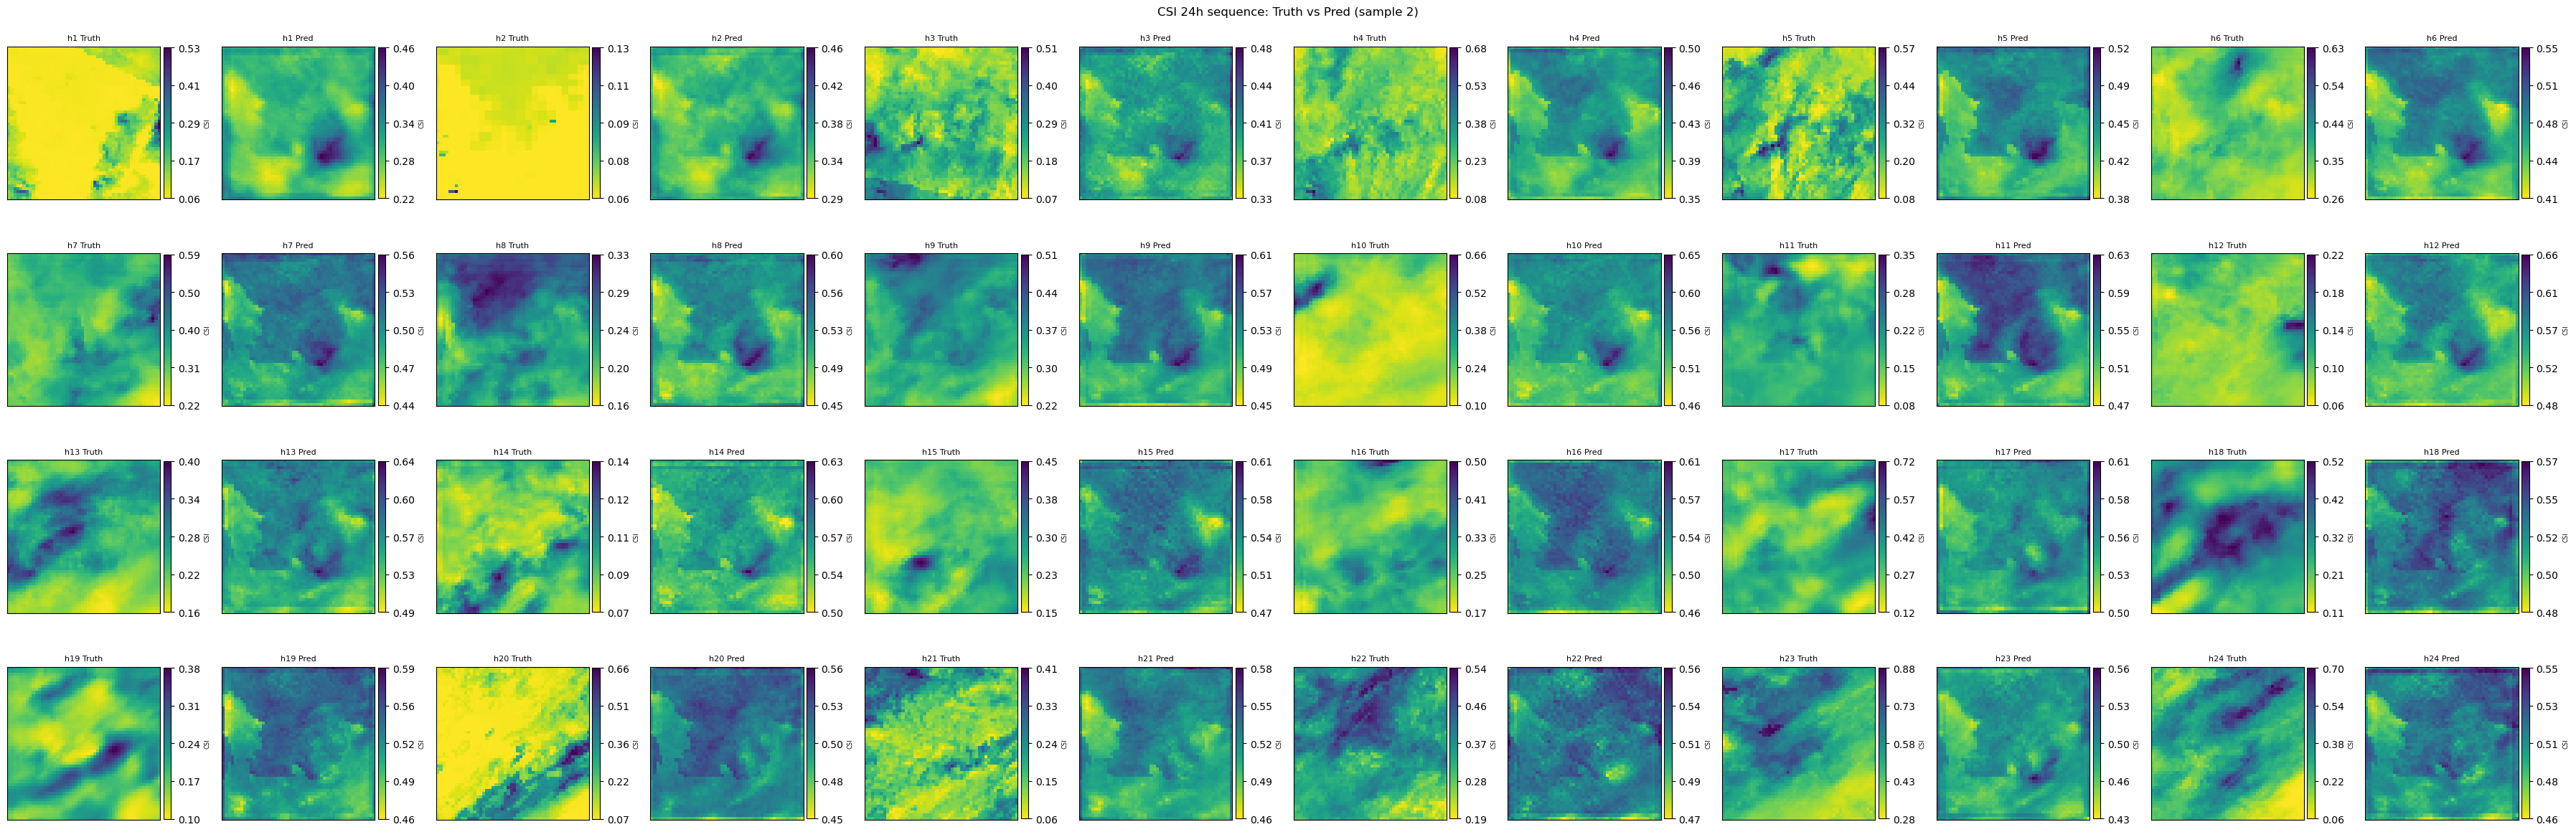

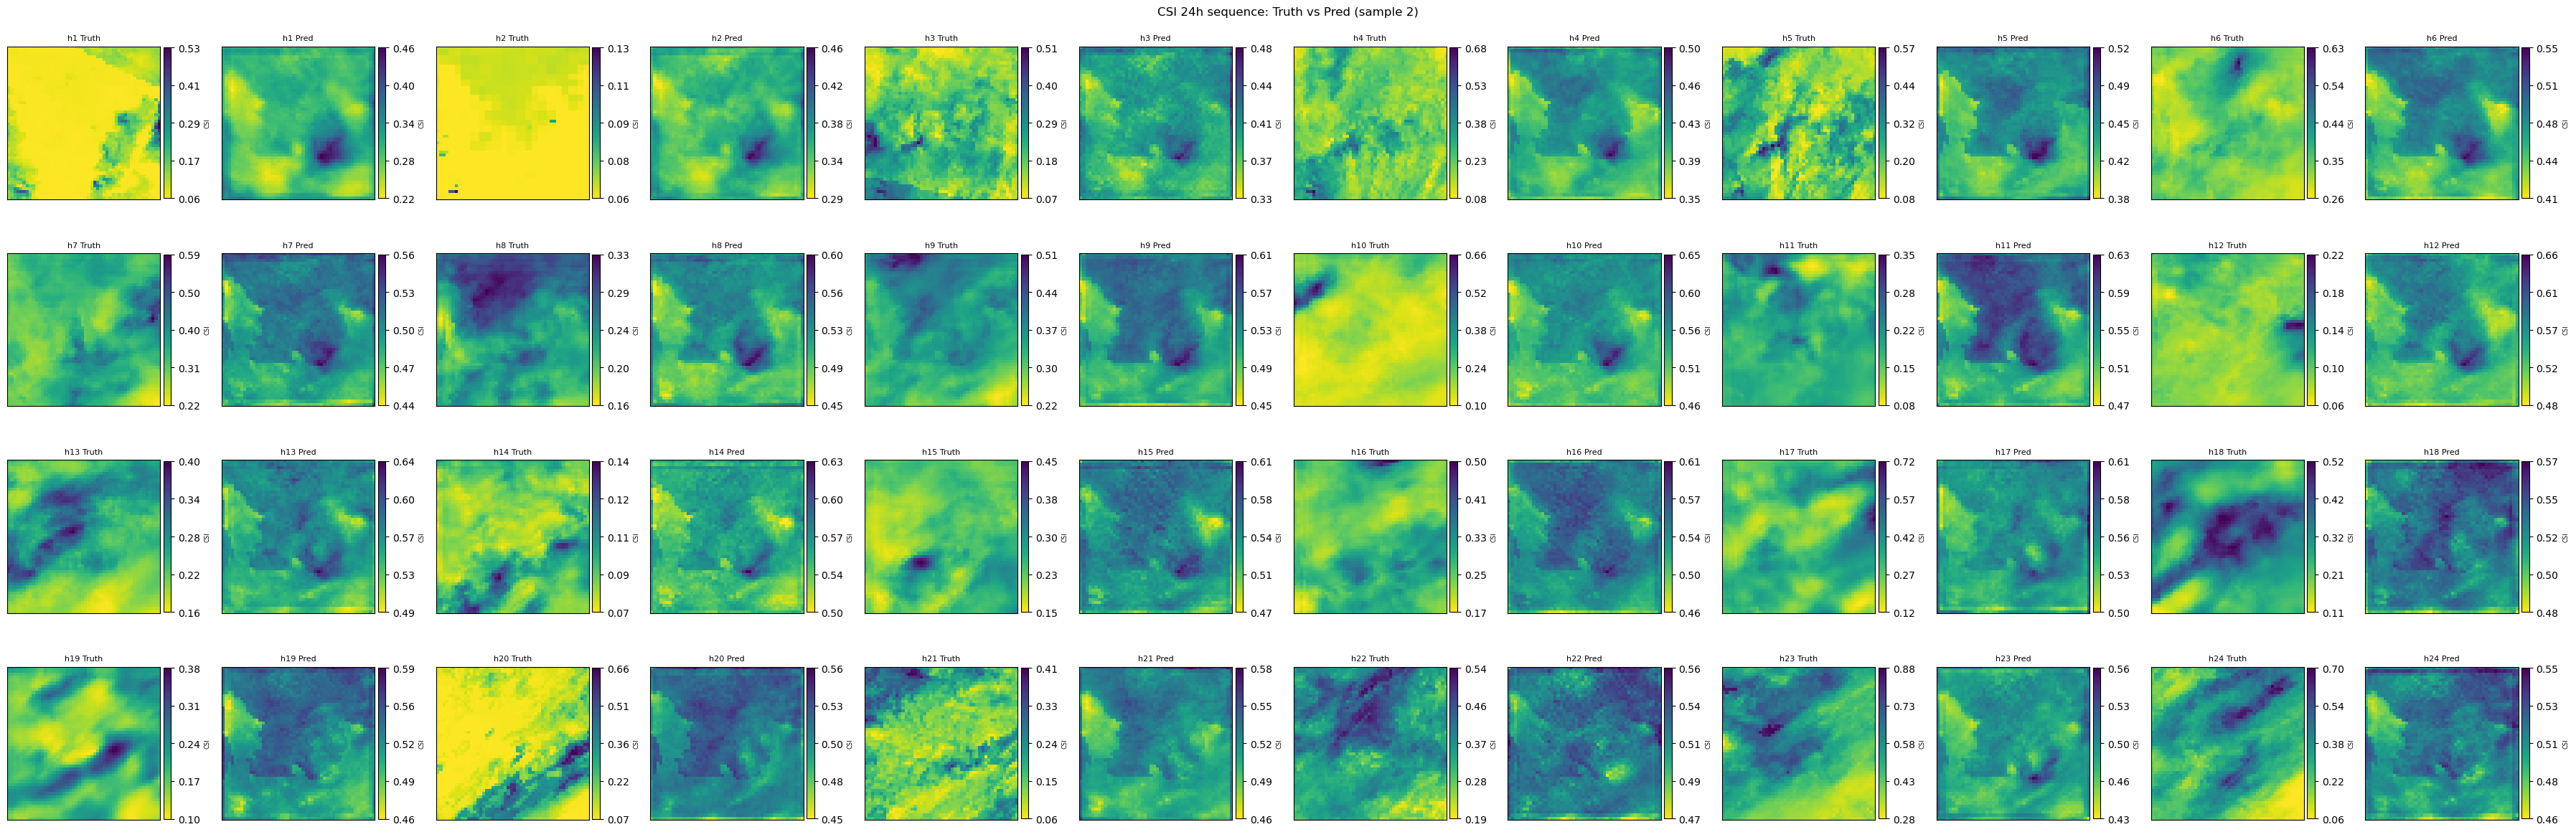

In [30]:
plot_24h_from_loader_5d_model(model,test_loader, device,batch_idx=1, sample_in_batch=2, start_lead=0, num_steps=24)

In [ ]:
combined = np.load("Data/CAMS/modeldata/combined_cams_data_no_syn.npz")
bands_npz = np.load("Data/BANDS/modeldata/bands_night_paired_twillight.npz")

time_all = combined["time_min"]          # (T,)
data_all = combined["data"]              # (T, 2, H, W)

time_band = bands_npz["time_min"]        # (N,)
bands_all = bands_npz["bands"]           # (N, C, H, W)

T, _, H, W = data_all.shape


In [42]:
eps = 1e-6
ghi = data_all[:, 0]
ghi_cs = data_all[:, 1]
csi_all = ghi / np.maximum(ghi_cs, eps)   # (T, H, W)


NameError: name 'data_all' is not defined

In [ ]:
eps = 1e-6
ghi = data_all[:, 0]
ghi_cs = data_all[:, 1]
csi_all = ghi / np.maximum(ghi_cs, eps)   # (T, H, W)


In [ ]:
bands_night = bands[band_idx]   # aligned with shared_idx

In [ ]:
device = next(model.parameters()).device
model.eval()

with torch.no_grad():
    x = torch.from_numpy(bands_night).float().to(device)
    y_hat = model(x)

    if y_hat.ndim == 4 and y_hat.shape[1] == 1:
        y_hat = y_hat[:, 0]     # (N, H, W)

    syn_csi = y_hat.cpu().numpy()  # (N, H, W)


In [ ]:
csi_syn_all = csi_all.copy()
csi_syn_all[shared_idx] = syn_csi


In [55]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

split_seed = 42
train_frac, val_frac, test_frac = 0.70, 0.15, 0.15
assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-9

all_ids = np.arange(len(full_ds))

train_ids, temp_ids = train_test_split(
    all_ids, test_size=(1.0 - train_frac), random_state=split_seed, shuffle=True
)

val_size_relative = val_frac / (val_frac + test_frac)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=(1.0 - val_size_relative), random_state=split_seed, shuffle=True
)

train_ds = Subset(full_ds, train_ids.tolist())
val_ds   = Subset(full_ds, val_ids.tolist())
test_ds  = Subset(full_ds, test_ids.tolist())

len(train_ds), len(val_ds), len(test_ds)


(12197, 2614, 2614)

In [51]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

xb_csi, yb_csi, yb_ghi, yb_cs = next(iter(train_loader))
xb_csi.shape, yb_csi.shape, yb_ghi.shape, yb_cs.shape


(torch.Size([32, 72, 50, 50]),
 torch.Size([32, 24, 50, 50]),
 torch.Size([32, 24, 50, 50]),
 torch.Size([32, 24, 50, 50]))

In [52]:
class SmartPersistenceCSI(torch.nn.Module):
    def __init__(self, out_len: int):
        super().__init__()
        self.out_len = out_len

    @torch.no_grad()
    def forward(self, x):
        last = x[:, -1:, :, :]  # (B,1,H,W)
        return last.repeat(1, self.out_len, 1, 1)

model = SmartPersistenceCSI(out_len).to(device)
model.eval()


SmartPersistenceCSI()

In [53]:
def masked_mae_rmse(y_hat, y, mask):
    diff = (y_hat - y)[mask]
    if diff.numel() == 0:
        return float("nan"), float("nan")
    mae = diff.abs().mean().item()
    rmse = torch.sqrt((diff * diff).mean()).item()
    return mae, rmse


In [54]:
import numpy as np
import torch

@torch.no_grad()
def evaluate(loader, name: str, model, device: str, daylight_thresh: float = 10.0):
    # CSI accumulators
    csi_abs_sum = 0.0
    csi_sse = 0.0              # sum squared error
    csi_y_sum = 0.0
    csi_y_sq_sum = 0.0

    # GHI accumulators
    ghi_abs_sum = 0.0
    ghi_sse = 0.0
    ghi_y_sum = 0.0
    ghi_y_sq_sum = 0.0

    count = 0  # number of valid elements under mask

    for x_csi, y_csi, y_ghi, y_cs in loader:
        x_csi = x_csi.to(device)
        y_csi = y_csi.to(device)
        y_ghi = y_ghi.to(device)
        y_cs  = y_cs.to(device)

        # Predict CSI
        y_hat_csi = model(x_csi)
        # Convert to GHI prediction
        y_hat_ghi = y_hat_csi * y_cs

        # Daylight mask
        mask = (y_cs > daylight_thresh)

        # Flatten masked values
        y_csi_m = y_csi[mask]
        y_hat_csi_m = y_hat_csi[mask]

        y_ghi_m = y_ghi[mask]
        y_hat_ghi_m = y_hat_ghi[mask]

        n = y_csi_m.numel()
        if n == 0:
            continue

        # CSI errors
        csi_diff = y_hat_csi_m - y_csi_m
        csi_abs_sum += csi_diff.abs().sum().item()
        csi_sse += (csi_diff * csi_diff).sum().item()
        csi_y_sum += y_csi_m.sum().item()
        csi_y_sq_sum += (y_csi_m * y_csi_m).sum().item()

        # GHI errors
        ghi_diff = y_hat_ghi_m - y_ghi_m
        ghi_abs_sum += ghi_diff.abs().sum().item()
        ghi_sse += (ghi_diff * ghi_diff).sum().item()
        ghi_y_sum += y_ghi_m.sum().item()
        ghi_y_sq_sum += (y_ghi_m * y_ghi_m).sum().item()

        count += n

    if count == 0:
        print(f"{name:>5s} | No daylight points (mask threshold too high?)")
        return

    # MAE / RMSE
    csi_mae  = csi_abs_sum / count
    csi_rmse = (csi_sse / count) ** 0.5
    ghi_mae  = ghi_abs_sum / count
    ghi_rmse = (ghi_sse / count) ** 0.5

    # R^2 (global)
    # TSS = sum((y - ybar)^2) = sum(y^2) - (sum(y)^2)/n
    csi_tss = csi_y_sq_sum - (csi_y_sum * csi_y_sum) / count
    ghi_tss = ghi_y_sq_sum - (ghi_y_sum * ghi_y_sum) / count

    csi_r2 = float("nan") if csi_tss <= 0 else (1.0 - csi_sse / csi_tss)
    ghi_r2 = float("nan") if ghi_tss <= 0 else (1.0 - ghi_sse / ghi_tss)

    print(
        f"{name:>5s} | "
        f"CSI: MAE={csi_mae:.6f} RMSE={csi_rmse:.6f} R2={csi_r2:.4f} | "
        f"GHI: MAE={ghi_mae:.3f} RMSE={ghi_rmse:.3f} R2={ghi_r2:.4f} | "
        f"mask ghi_cs>{daylight_thresh} (n={count})"
    )

# run
daylight_thresh = 10.0
evaluate(train_loader, "TRAIN", model, device, daylight_thresh)
evaluate(val_loader,   "VAL",   model, device, daylight_thresh)
evaluate(test_loader,  "TEST",  model, device, daylight_thresh)


TRAIN | CSI: MAE=0.435773 RMSE=0.569056 R2=-2.4534 | GHI: MAE=222.240 RMSE=336.815 R2=-0.4194 | mask ghi_cs>10.0 (n=369808109)
  VAL | CSI: MAE=0.425862 RMSE=0.559940 R2=-2.3503 | GHI: MAE=216.373 RMSE=330.221 R2=-0.3833 | mask ghi_cs>10.0 (n=79056704)
 TEST | CSI: MAE=0.424815 RMSE=0.558986 R2=-2.3275 | GHI: MAE=216.175 RMSE=330.194 R2=-0.3643 | mask ghi_cs>10.0 (n=79265719)


In [16]:
# pick one sample
x, y, y_cs,cs = test_ds[0]
x = x.unsqueeze(0).to(device)
y_hat = model(x).cpu().numpy()[0]   # (24,H,W)

print("Input last timestep CSI stats:", x[:, -1].cpu().numpy().min(), x[:, -1].cpu().numpy().max())
print("Pred horizon CSI stats:", y_hat.min(), y_hat.max())


Input last timestep CSI stats: 0.061553463 0.7303551
Pred horizon CSI stats: 0.061553463 0.7303551


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class TinyResBlock2D(nn.Module):
    def __init__(self, ch: int, dropout: float = 0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.norm1 = nn.GroupNorm(num_groups=min(4, ch), num_channels=ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.norm2 = nn.GroupNorm(num_groups=min(4, ch), num_channels=ch)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        h = F.silu(self.norm1(self.conv1(x)))
        h = self.drop(h)
        h = self.norm2(self.conv2(h))
        return F.silu(x + h)

class CNN2DTimeChannelsLite(nn.Module):
    """
    Input:  (B, Tin, H, W)  where Tin=72
    Output: (B, Tout, H, W) where Tout=24
    """
    def __init__(self, tin=72, tout=24, hidden=32, depth=3, dropout=0.1):
        super().__init__()
        self.proj_in = nn.Sequential(
            nn.Conv2d(tin, hidden, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=min(4, hidden), num_channels=hidden),
            nn.SiLU(),
        )
        self.blocks = nn.Sequential(*[TinyResBlock2D(hidden, dropout=dropout) for _ in range(depth)])
        self.proj_out = nn.Conv2d(hidden, tout, kernel_size=1)

    def forward(self, x):
        return self.proj_out(self.blocks(self.proj_in(x)))


In [13]:
model = CNN2DTimeChannelsLite(tin=72, tout=24, hidden=32, depth=3, dropout=0.1).to(device)

x_csi, y_csi, y_ghi, y_cs = next(iter(train_loader))
y_hat_csi = model(x_csi.to(device))
print(y_hat_csi.shape)  # (B,24,H,W)


torch.Size([32, 24, 50, 50])


In [11]:
(0.103-0.13)/0.13

-0.20769230769230776

In [13]:
(61.72-67.1)/67.1

-0.08017883755588667

In [51]:
import copy
import numpy as np
import torch
import torch.nn.functional as F

def masked_huber_loss(y_hat, y, mask, delta=0.1):
    """
    Huber (SmoothL1) on masked elements only.
    y_hat, y: (B, Tout, H, W)
    mask: same shape boolean
    """
    diff = (y_hat - y)[mask]
    if diff.numel() == 0:
        # no daylight points -> return 0 loss (rare if threshold reasonable)
        return y_hat.new_tensor(0.0)
    # SmoothL1 on scalar vector
    return F.smooth_l1_loss(diff, torch.zeros_like(diff), beta=delta)



In [52]:
import math
import torch

def evaluate(loader, name: str, model, device: str, daylight_thresh: float = 10.0, lead_axis: int = 1):
    # pooled (all leads)
    csi_abs_sum = csi_sse = csi_y_sum = csi_y_sq_sum = 0.0
    ghi_abs_sum = ghi_sse = ghi_y_sum = ghi_y_sq_sum = 0.0
    count_all = 0

    lead_dim = None

    # per-lead
    csi_sse_L = csi_cnt_L = None
    ghi_sse_L = ghi_cnt_L = None

    model.eval()
    with torch.no_grad():
        for x_csi, y_csi, y_ghi, y_cs in loader:
            x_csi = x_csi.to(device)
            y_csi = y_csi.to(device)
            y_ghi = y_ghi.to(device)
            y_cs  = y_cs.to(device)

            y_hat_csi = model(x_csi)
            y_hat_csi = torch.clamp(y_hat_csi, 0.0, 2.0)  # optional
            y_hat_ghi = y_hat_csi * y_cs

            # infer lead dimension correctly (for [B, L, ...], L is axis=1)
            if lead_dim is None:
                if y_csi.ndim == 1:
                    lead_dim = 1
                else:
                    lead_dim = y_csi.shape[lead_axis]
                csi_sse_L = [0.0] * lead_dim
                csi_cnt_L = [0]   * lead_dim
                ghi_sse_L = [0.0] * lead_dim
                ghi_cnt_L = [0]   * lead_dim

            mask = (y_cs > daylight_thresh)

            # Single-lead (no lead axis)
            if lead_dim == 1 and y_csi.ndim == 1:
                y_csi_m = y_csi[mask]
                y_hat_csi_m = y_hat_csi[mask]
                y_ghi_m = y_ghi[mask]
                y_hat_ghi_m = y_hat_ghi[mask]

                n = y_csi_m.numel()
                if n == 0:
                    continue

                csi_diff = y_hat_csi_m - y_csi_m
                ghi_diff = y_hat_ghi_m - y_ghi_m

                csi_abs_sum += csi_diff.abs().sum().item()
                csi_sse     += (csi_diff * csi_diff).sum().item()
                csi_y_sum   += y_csi_m.sum().item()
                csi_y_sq_sum+= (y_csi_m * y_csi_m).sum().item()

                ghi_abs_sum += ghi_diff.abs().sum().item()
                ghi_sse     += (ghi_diff * ghi_diff).sum().item()
                ghi_y_sum   += y_ghi_m.sum().item()
                ghi_y_sq_sum+= (y_ghi_m * y_ghi_m).sum().item()

                count_all += n

                csi_sse_L[0] += (csi_diff * csi_diff).sum().item()
                csi_cnt_L[0] += int(n)
                ghi_sse_L[0] += (ghi_diff * ghi_diff).sum().item()
                ghi_cnt_L[0] += int(n)
                continue

            # Multi-lead: assume shape [B, L, ...] (lead_axis=1 by default)
            # We'll index lead by selecting along lead_axis.
            for t in range(lead_dim):
                y_csi_t = y_csi.select(lead_axis, t)
                y_hat_csi_t = y_hat_csi.select(lead_axis, t)
                y_ghi_t = y_ghi.select(lead_axis, t)
                y_hat_ghi_t = y_hat_ghi.select(lead_axis, t)
                mask_t = mask.select(lead_axis, t)

                y_csi_m = y_csi_t[mask_t]
                y_hat_csi_m = y_hat_csi_t[mask_t]
                y_ghi_m = y_ghi_t[mask_t]
                y_hat_ghi_m = y_hat_ghi_t[mask_t]

                n = y_csi_m.numel()
                if n == 0:
                    continue

                csi_diff = y_hat_csi_m - y_csi_m
                ghi_diff = y_hat_ghi_m - y_ghi_m

                # pooled
                csi_abs_sum += csi_diff.abs().sum().item()
                csi_sse     += (csi_diff * csi_diff).sum().item()
                csi_y_sum   += y_csi_m.sum().item()
                csi_y_sq_sum+= (y_csi_m * y_csi_m).sum().item()

                ghi_abs_sum += ghi_diff.abs().sum().item()
                ghi_sse     += (ghi_diff * ghi_diff).sum().item()
                ghi_y_sum   += y_ghi_m.sum().item()
                ghi_y_sq_sum+= (y_ghi_m * y_ghi_m).sum().item()

                count_all += n

                # per-lead
                csi_sse_L[t] += (csi_diff * csi_diff).sum().item()
                csi_cnt_L[t] += int(n)
                ghi_sse_L[t] += (ghi_diff * ghi_diff).sum().item()
                ghi_cnt_L[t] += int(n)

    if count_all == 0:
        print(f"{name:>5s} | No daylight points (threshold too high?)")
        return {"count": 0}

    csi_mae  = csi_abs_sum / count_all
    csi_rmse = math.sqrt(csi_sse / count_all)
    ghi_mae  = ghi_abs_sum / count_all
    ghi_rmse = math.sqrt(ghi_sse / count_all)

    csi_tss = csi_y_sq_sum - (csi_y_sum * csi_y_sum) / count_all
    ghi_tss = ghi_y_sq_sum - (ghi_y_sum * ghi_y_sum) / count_all
    csi_r2 = float("nan") if csi_tss <= 0 else (1.0 - csi_sse / csi_tss)
    ghi_r2 = float("nan") if ghi_tss <= 0 else (1.0 - ghi_sse / ghi_tss)

    print(
        f"{name:>5s} | "
        f"CSI: MAE={csi_mae:.6f} RMSE={csi_rmse:.6f} R2={csi_r2:.4f} | "
        f"GHI: MAE={ghi_mae:.3f} RMSE={ghi_rmse:.3f} R2={ghi_r2:.4f} | "
        f"mask ghi_cs>{daylight_thresh} (n={count_all})"
    )

    print(f"{name:>5s} | Per-lead RMSE (lead_axis={lead_axis}, daylight only):")
    print(" lead |  CSI_RMSE   |  GHI_RMSE   |   n")
    per_csi_rmse = []
    per_ghi_rmse = []
    for t in range(lead_dim):
        n = csi_cnt_L[t]
        c_rmse = float("nan") if n == 0 else math.sqrt(csi_sse_L[t] / n)
        g_rmse = float("nan") if n == 0 else math.sqrt(ghi_sse_L[t] / n)
        per_csi_rmse.append(c_rmse)
        per_ghi_rmse.append(g_rmse)
        print(f"{t:5d} | {c_rmse:10.6f} | {g_rmse:10.3f} | {n:5d}")

    return {
        "count": count_all,
        "csi_mae": csi_mae, "csi_rmse": csi_rmse, "csi_r2": csi_r2,
        "ghi_mae": ghi_mae, "ghi_rmse": ghi_rmse, "ghi_r2": ghi_r2,
        "per_lead": {"csi_rmse": per_csi_rmse, "ghi_rmse": per_ghi_rmse, "n": csi_cnt_L},
    }


In [53]:
def train_one_epoch(loader, model, optimizer, device: str, daylight_thresh: float = 10.0, huber_delta: float = 0.1, clip_grad: float = 1.0):
    model.train()
    total_loss = 0.0
    steps = 0

    for x_csi, y_csi, y_ghi, y_cs in loader:
        x_csi = x_csi.to(device)
        y_csi = y_csi.to(device)
        y_cs  = y_cs.to(device)

        optimizer.zero_grad(set_to_none=True)

        y_hat = model(x_csi)
        y_hat = torch.clamp(y_hat, 0.0, 2.0)  # optional but often stabilizes CSI

        mask = (y_cs > daylight_thresh)

        loss = masked_huber_loss(y_hat, y_csi, mask, delta=huber_delta)
        loss.backward()

        if clip_grad is not None and clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)

        optimizer.step()

        total_loss += loss.item()
        steps += 1

    return total_loss / max(steps, 1)


In [54]:
import torch

# ---- hyperparams
lr = 2e-4
weight_decay = 1e-4
epochs = 30
daylight_thresh = 10.0
huber_delta = 0.1
clip_grad = 1.0
patience = 6  # early stopping on val CSI RMSE

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

best_state = None
best_val = float("inf")
bad_epochs = 0

# initial eval
evaluate(train_loader, "TRAIN", model, device, daylight_thresh)
evaluate(val_loader,   "VAL",   model, device, daylight_thresh)

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        train_loader, model, optimizer, device,
        daylight_thresh=daylight_thresh,
        huber_delta=huber_delta,
        clip_grad=clip_grad
    )

    val_metrics = evaluate(val_loader, "VAL", model, device, daylight_thresh)
    val_rmse = val_metrics.get("csi_rmse", float("inf"))

    scheduler.step(val_rmse)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_csi_rmse={val_rmse:.6f} | lr={lr_now:.2e}")


# restore best
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model (val CSI RMSE={best_val:.6f}).")


TRAIN | CSI: MAE=0.184878 RMSE=0.248704 R2=0.3404 | GHI: MAE=94.597 RMSE=147.089 R2=0.7293 | mask ghi_cs>10.0 (n=369808109)
TRAIN | Per-lead RMSE (lead_axis=1, daylight only):
 lead |  CSI_RMSE   |  GHI_RMSE   |   n
    0 |   0.158861 |     81.527 | 15271119
    1 |   0.194089 |    102.399 | 15292017
    2 |   0.213812 |    116.296 | 15315862
    3 |   0.224665 |    127.720 | 15367681
    4 |   0.235778 |    137.808 | 15387972
    5 |   0.243399 |    145.945 | 15370482
    6 |   0.246707 |    149.187 | 15424611
    7 |   0.250702 |    151.609 | 15454511
    8 |   0.254420 |    153.077 | 15464335
    9 |   0.258220 |    154.533 | 15489017
   10 |   0.257747 |    153.333 | 15556457
   11 |   0.256393 |    153.807 | 15598145
   12 |   0.259735 |    155.079 | 15558369
   13 |   0.259098 |    154.992 | 15468369
   14 |   0.258769 |    153.871 | 15498584
   15 |   0.261759 |    155.530 | 15491587
   16 |   0.260854 |    155.913 | 15450283
   17 |   0.260555 |    155.852 | 15379261
   18 |   

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def plot_csi_ghi_prediction(
    loader,
    model,
    device: str,
    batch_index: int = 0,
    mode: str = "mean",          # "mean" or "pixel"
    pixel: tuple = (25, 25),     # used if mode="pixel"
    daylight_thresh: float = 10.0,
    clamp_csi=(0.0, 2.0),
    title_prefix: str = ""
):
    """
    Plots real vs predicted CSI and GHI for one sample from one batch.
    loader yields: x_csi, y_csi, y_ghi, y_cs
    """

    model.eval()
    x_csi, y_csi, y_ghi, y_cs = next(iter(loader))

    # select one item in batch
    x_csi = x_csi[batch_index:batch_index+1].to(device)
    y_csi = y_csi[batch_index:batch_index+1].to(device)
    y_ghi = y_ghi[batch_index:batch_index+1].to(device)
    y_cs  = y_cs[batch_index:batch_index+1].to(device)

    y_hat_csi = model(x_csi)
    if clamp_csi is not None:
        y_hat_csi = torch.clamp(y_hat_csi, clamp_csi[0], clamp_csi[1])
    y_hat_ghi = y_hat_csi * y_cs

    # reduce to 1D time series (Tout,)
    if mode == "mean":
        # mean over H,W
        y_csi_ts = y_csi.mean(dim=(-2, -1)).squeeze(0).detach().cpu().numpy()
        y_hat_csi_ts = y_hat_csi.mean(dim=(-2, -1)).squeeze(0).detach().cpu().numpy()

        y_ghi_ts = y_ghi.mean(dim=(-2, -1)).squeeze(0).detach().cpu().numpy()
        y_hat_ghi_ts = y_hat_ghi.mean(dim=(-2, -1)).squeeze(0).detach().cpu().numpy()

        y_cs_ts = y_cs.mean(dim=(-2, -1)).squeeze(0).detach().cpu().numpy()
        label_extra = "spatial mean"
    elif mode == "pixel":
        py, px = pixel
        y_csi_ts = y_csi[0, :, py, px].detach().cpu().numpy()
        y_hat_csi_ts = y_hat_csi[0, :, py, px].detach().cpu().numpy()

        y_ghi_ts = y_ghi[0, :, py, px].detach().cpu().numpy()
        y_hat_ghi_ts = y_hat_ghi[0, :, py, px].detach().cpu().numpy()

        y_cs_ts = y_cs[0, :, py, px].detach().cpu().numpy()
        label_extra = f"pixel (y={py}, x={px})"
    else:
        raise ValueError("mode must be 'mean' or 'pixel'")

    t = np.arange(len(y_csi_ts))

    # mask for visualization
    daylight = y_cs_ts > daylight_thresh

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # CSI
    axes[0].plot(t, y_csi_ts, label="CSI true")
    axes[0].plot(t, y_hat_csi_ts, label="CSI pred")
    axes[0].scatter(t[~daylight], y_csi_ts[~daylight], s=15, label="night/low-cs (masked)")
    axes[0].set_ylabel("CSI")
    axes[0].set_title(f"{title_prefix}CSI ({label_extra})")
    axes[0].legend()

    # GHI
    axes[1].plot(t, y_ghi_ts, label="GHI true")
    axes[1].plot(t, y_hat_ghi_ts, label="GHI pred")
    axes[1].scatter(t[~daylight], y_ghi_ts[~daylight], s=15, label="night/low-cs (masked)")
    axes[1].set_ylabel("GHI")
    axes[1].set_xlabel("Forecast step (0..23)")
    axes[1].set_title(f"{title_prefix}GHI ({label_extra})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


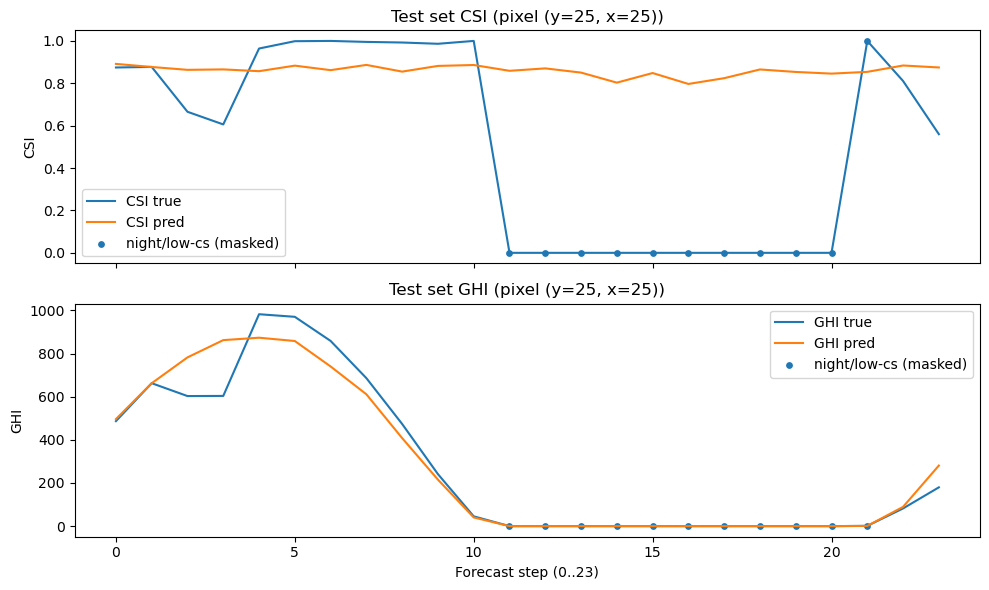

In [29]:
plot_csi_ghi_prediction(
    test_loader,
    model,
    device,
    batch_index=3,
    mode="pixel",
    daylight_thresh=10.0,
    clamp_csi=(0.0, 2.0),
    title_prefix="Test set ",
)

In [40]:
evaluate(test_loader, name ="test", model=model, device=device, daylight_thresh = 10.0)

 test | CSI: MAE=0.188479 RMSE=0.252362 R2=0.3218 | GHI: MAE=96.312 RMSE=148.589 R2=0.7237 | mask ghi_cs>10.0 (n=79265719)
 test | Per-lead RMSE (lead_axis=1, daylight only):
 lead |  CSI_RMSE   |  GHI_RMSE   |   n
    0 |   0.157871 |     82.499 | 3374275
    1 |   0.195119 |    103.843 | 3384912
    2 |   0.209233 |    118.140 | 3346157
    3 |   0.221613 |    130.084 | 3308031
    4 |   0.229190 |    138.197 | 3286274
    5 |   0.243809 |    145.593 | 3323896
    6 |   0.252938 |    150.134 | 3360357
    7 |   0.258398 |    155.859 | 3310683
    8 |   0.260444 |    156.875 | 3326175
    9 |   0.265702 |    157.589 | 3306038
   10 |   0.268839 |    156.147 | 3291028
   11 |   0.266680 |    156.998 | 3209577
   12 |   0.266254 |    158.432 | 3245837
   13 |   0.265405 |    158.610 | 3244535
   14 |   0.267178 |    159.018 | 3243006
   15 |   0.267401 |    158.651 | 3273226
   16 |   0.265674 |    158.024 | 3290133
   17 |   0.259919 |    154.743 | 3310469
   18 |   0.265141 |    157.0

{'count': 79265719,
 'csi_mae': 0.1884791339598423,
 'csi_rmse': 0.25236194590688404,
 'csi_r2': 0.32179312768080115,
 'ghi_mae': 96.3124297528923,
 'ghi_rmse': 148.5894551388636,
 'ghi_r2': 0.7237234406602262,
 'per_lead': {'csi_rmse': [0.15787057161499132,
   0.1951192566554157,
   0.2092328871681167,
   0.22161296090581617,
   0.2291896115040969,
   0.24380888941774254,
   0.25293794160316113,
   0.25839845435767994,
   0.26044447718139807,
   0.2657015125683442,
   0.2688386657703814,
   0.2666801778036591,
   0.266254415151739,
   0.2654045079675201,
   0.2671781679492518,
   0.2674010156061313,
   0.2656738602434078,
   0.2599187881319647,
   0.2651411875695519,
   0.26872102577904455,
   0.2688176265978702,
   0.26672180839661797,
   0.26474826377908794,
   0.26843130005265026],
  'ghi_rmse': [82.49862559185172,
   103.8432380365035,
   118.13985780449985,
   130.08358652456627,
   138.1971367963505,
   145.59253840947807,
   150.13443516159882,
   155.85859645164695,
   156.875

In [46]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

import torch

def get_one_batch_predictions(loader, model, device, clamp=(0.0, 2.0)):
    """
    Returns:
      y_csi, y_hat_csi, y_ghi, y_hat_ghi, y_cs
    Shapes expected: [B, L, H, W]
    """
    model.eval()
    with torch.no_grad():
        x_csi, y_csi, y_ghi, y_cs = next(iter(loader))
        x_csi = x_csi.to(device)
        y_csi = y_csi.to(device)
        y_ghi = y_ghi.to(device)
        y_cs  = y_cs.to(device)

        y_hat_csi = model(x_csi)
        if clamp is not None:
            y_hat_csi = torch.clamp(y_hat_csi, clamp[0], clamp[1])

        y_hat_ghi = y_hat_csi * y_cs

    return y_csi, y_hat_csi, y_ghi, y_hat_ghi, y_cs

import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_24h_pred_vs_truth_side_by_side(
    y_true,
    y_pred,
    *,
    sample_idx: int = 0,
    start_lead: int = 0,
    num_steps: int = 24,
    cols: int = 6,
    cmap: str = "viridis_r",
    var_name: str = "CSI",
    lead_label: str = "h",          # "h" -> h1..h24
    figsize_per_cell: float = 3.0,  # similar feel to your code
):
    """
    Plot 24-hour sequence as side-by-side panels per lead: [Truth | Pred].
    Each subplot gets its OWN colorbar, with ticks spanning that subplot's vmin..vmax
    (matching your plot_csi_sorted_sequence_exact style).

    Expected shapes:
      - y_true, y_pred: torch.Tensor or np.ndarray
        [B, L, H, W] or [L, H, W]
    """
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu()
        return np.asarray(x)

    y_true = to_numpy(y_true)
    y_pred = to_numpy(y_pred)

    # normalize to [L, H, W]
    if y_true.ndim == 4:
        y_true = y_true[sample_idx]
    if y_pred.ndim == 4:
        y_pred = y_pred[sample_idx]

    if y_true.ndim != 3 or y_pred.ndim != 3:
        raise ValueError(f"Need [L,H,W]. Got y_true {y_true.shape}, y_pred {y_pred.shape}")

    L = y_true.shape[0]
    end_lead = min(start_lead + num_steps, L)
    frames = end_lead - start_lead
    if frames <= 0:
        raise ValueError("Empty range; check start_lead/num_steps")

    # grid: rows x (2*cols) because each lead uses 2 panels (truth, pred)
    rows = int(np.ceil(frames / cols))
    fig, axes = plt.subplots(
        rows, 2 * cols,
        figsize=(figsize_per_cell * (2 * cols), figsize_per_cell * rows)
    )
    axes = np.atleast_2d(axes)

    for i in range(frames):
        t = start_lead + i
        r = i // cols
        c = i % cols

        ax_truth = axes[r, 2 * c]
        ax_pred  = axes[r, 2 * c + 1]

        frame_truth = y_true[t]
        frame_pred  = y_pred[t]

        # --- Truth subplot: per-frame scale + per-axes colorbar with explicit ticks ---
        vmin_t = float(np.nanmin(frame_truth))
        vmax_t = float(np.nanmax(frame_truth))
        im_t = ax_truth.imshow(frame_truth, cmap=cmap, vmin=vmin_t, vmax=vmax_t)
        ax_truth.set_title(f"{lead_label}{t+1} Truth", fontsize=8)
        ax_truth.set_xticks([]); ax_truth.set_yticks([])

        cb_t = fig.colorbar(im_t, ax=ax_truth, fraction=0.046, pad=0.02)
        cb_t.set_label(var_name, fontsize=6)
        ticks_t = np.linspace(vmin_t, vmax_t, 5)
        cb_t.set_ticks(ticks_t)
        cb_t.set_ticklabels([f"{x:.2f}" for x in ticks_t])

        # --- Pred subplot: per-frame scale + per-axes colorbar with explicit ticks ---
        vmin_p = float(np.nanmin(frame_pred))
        vmax_p = float(np.nanmax(frame_pred))
        im_p = ax_pred.imshow(frame_pred, cmap=cmap, vmin=vmin_p, vmax=vmax_p)
        ax_pred.set_title(f"{lead_label}{t+1} Pred", fontsize=8)
        ax_pred.set_xticks([]); ax_pred.set_yticks([])

        cb_p = fig.colorbar(im_p, ax=ax_pred, fraction=0.046, pad=0.02)
        cb_p.set_label(var_name, fontsize=6)
        ticks_p = np.linspace(vmin_p, vmax_p, 5)
        cb_p.set_ticks(ticks_p)
        cb_p.set_ticklabels([f"{x:.2f}" for x in ticks_p])

    # hide unused axes (both truth+pred slots)
    used = frames
    total_slots = rows * cols
    for j in range(used, total_slots):
        r = j // cols
        c = j % cols
        axes[r, 2*c].axis("off")
        axes[r, 2*c + 1].axis("off")

    fig.suptitle(f"{var_name} 24h sequence: Truth vs Pred (sample {sample_idx})", fontsize=12)
    plt.tight_layout()
    plt.show()
    return fig


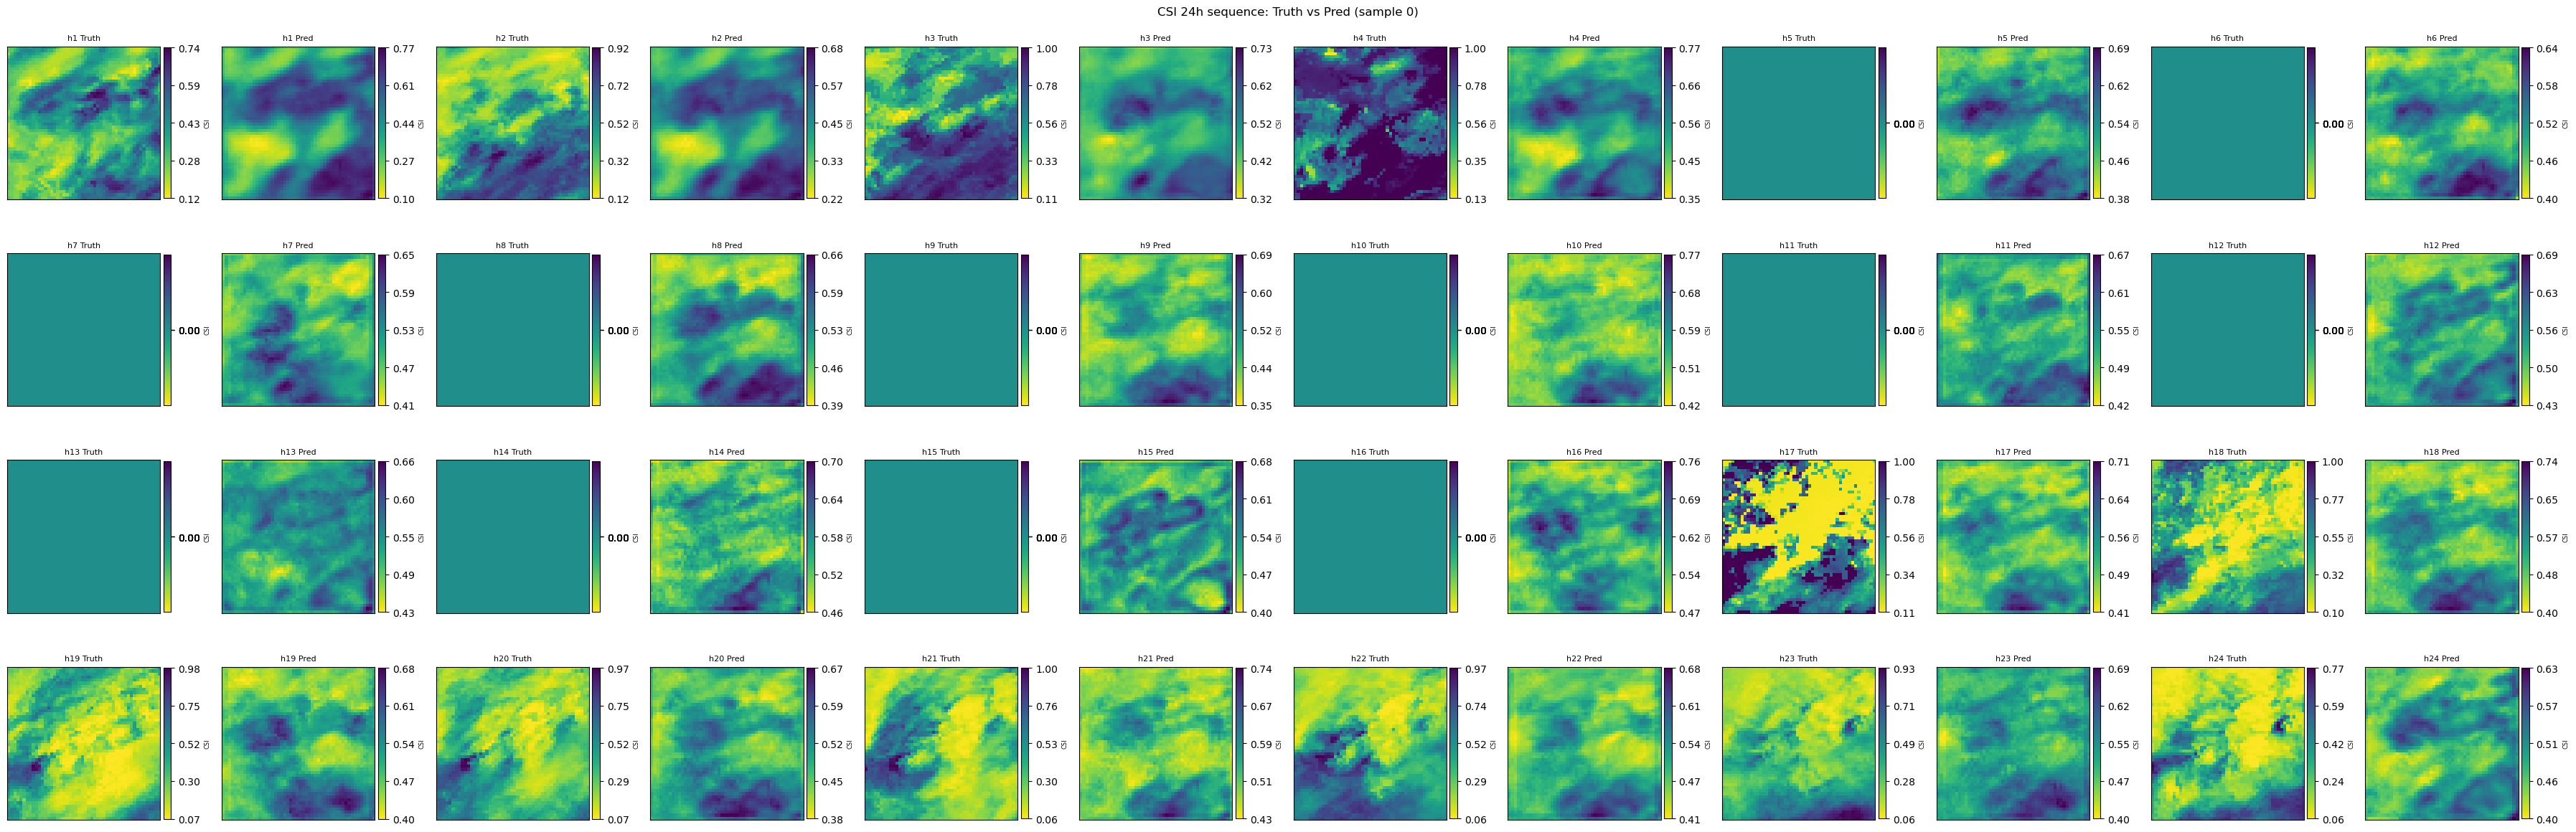

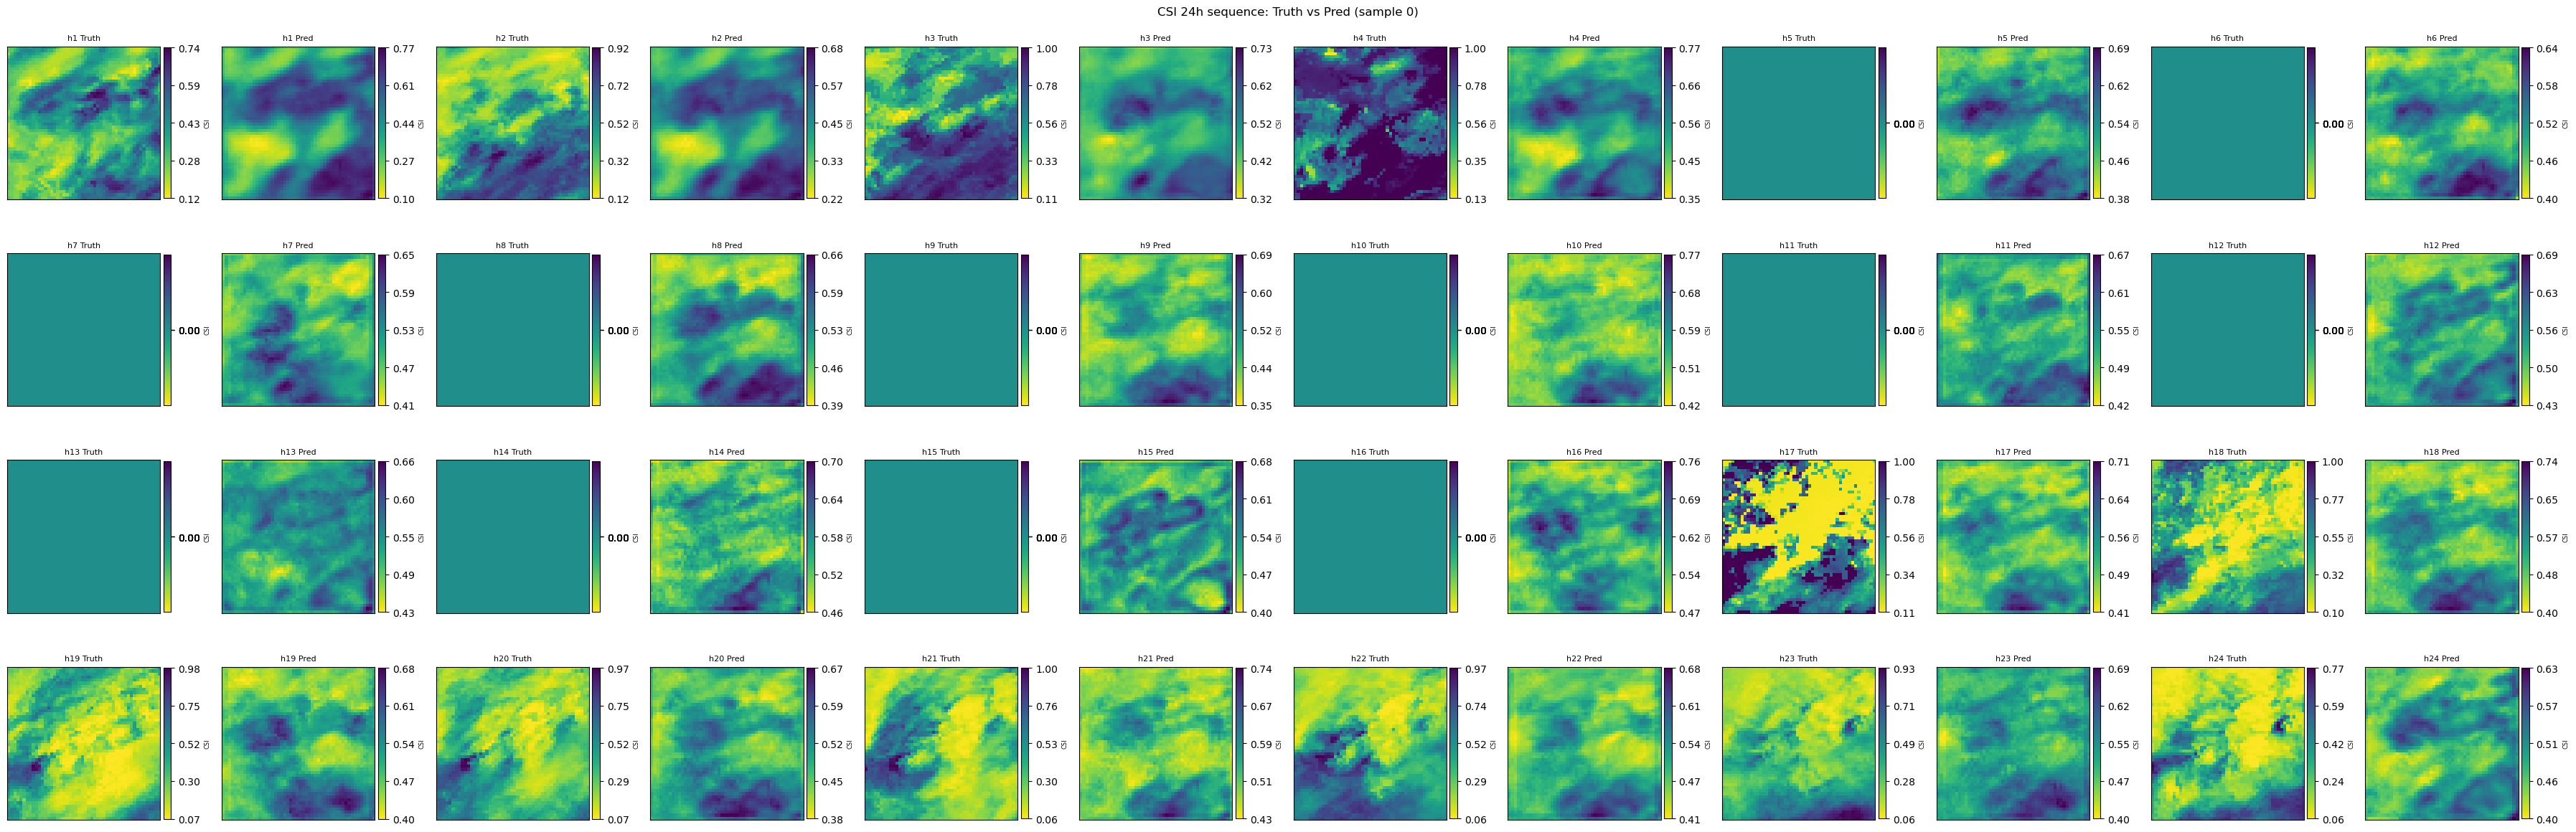

In [48]:
# CSI
plot_24h_pred_vs_truth_side_by_side(y_csi, y_hat_csi, sample_idx=0, var_name="CSI")
